# Improved Supervised Learning for MineRL Sparse Action Prediction

This notebook addresses the **sparse action problem** in MineRL data where:
- Actions like `craft`, `equip`, `place` occur only a few times across thousands of frames
- Standard models learn to predict "no action" and achieve high accuracy but 0 F1

## Strategies Implemented:
1. **Multi-player data aggregation** - Combine all 122 players for more training data
2. **Balanced sampling** - Undersample majority class to balance training
3. **Class weights** - Use scale_pos_weight in XGBoost
4. **State transition prediction** - Predict inventory changes instead of raw actions
5. **Game phase classification** - Predict high-level game phases
6. **Temporal window features** - Rich feature engineering over time windows
7. **Proper evaluation metrics** - Use PR-AUC and ROC-AUC instead of accuracy

---
## Section 0: Setup and Data Loading

In [ ]:
# Configuration
OBJECTIVE = "ObtainDiamond"
DATASET_NAME = f"MineRL{OBJECTIVE}-v0"
ZIPFILE = f"{DATASET_NAME}.zip"
DOWNLOAD_URL = f"https://zenodo.org/records/12659939/files/MineRL{OBJECTIVE}-v0.zip?download=1"

# Google Drive directory where data zipfile should be stored
DRIVE_DIR = "/content/drive/MyDrive/cis-5450-big-data/Project/"
DRIVE_ZIP_PATH = f"{DRIVE_DIR}/{ZIPFILE}"
LOCAL_ZIP_PATH = f"/content/{ZIPFILE}"

# How many players to use (set to None to use all)
MAX_PLAYERS = None  # Use all 122 players for more data

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os

if os.path.exists(DRIVE_ZIP_PATH):
    print(f"Zip file already exists in Drive: {DRIVE_ZIP_PATH}")
else:
    print("Zip file NOT found in Drive.")
    print("Downloading from source...")
    !wget -O {LOCAL_ZIP_PATH} {DOWNLOAD_URL}
    !cp {LOCAL_ZIP_PATH} {DRIVE_ZIP_PATH}
    print(f"Saved zip file to: {DRIVE_ZIP_PATH}")

Zip file already exists in Drive: /content/drive/MyDrive/cis-5450-big-data/Project//MineRLObtainDiamond-v0.zip


In [ ]:
# Extract the dataset
print("Copying ZIP file into runtime...")
!cp {DRIVE_ZIP_PATH} {LOCAL_ZIP_PATH}

print("Done!")
print(f"Local runtime now contains: {LOCAL_ZIP_PATH}")

!mkdir minerl
!unzip {LOCAL_ZIP_PATH} -d minerl

Copying ZIP file into runtime...
Done!
Local runtime now contains: /content/MineRLObtainDiamond-v0.zip
Archive:  /content/MineRLObtainDiamond-v0.zip
   creating: minerl/MineRLObtainDiamond-v0/
   creating: minerl/MineRLObtainDiamond-v0/v3_absolute_grape_changeling-17_418-2303/
 extracting: minerl/MineRLObtainDiamond-v0/v3_absolute_grape_changeling-17_418-2303/metadata.json  
 extracting: minerl/MineRLObtainDiamond-v0/v3_absolute_grape_changeling-17_418-2303/recording.mp4  
 extracting: minerl/MineRLObtainDiamond-v0/v3_absolute_grape_changeling-17_418-2303/rendered.npz  
   creating: minerl/MineRLObtainDiamond-v0/v3_absolute_grape_changeling-6_37339-46767/
 extracting: minerl/MineRLObtainDiamond-v0/v3_absolute_grape_changeling-6_37339-46767/metadata.json  
 extracting: minerl/MineRLObtainDiamond-v0/v3_absolute_grape_changeling-6_37339-46767/recording.mp4  
 extracting: minerl/MineRLObtainDiamond-v0/v3_absolute_grape_changeling-6_37339-46767/rendered.npz  
   creating: minerl/MineRLObtai

In [ ]:
import os
import shutil

def rename_subdirectories(objective: str) -> list:
    '''
    Rename extracted dataset subdirectories to player_0, player_1, etc.
    '''
    dataset_name = f"MineRL{objective}-v0"
    base_path = f"minerl/{dataset_name}"
    player_dirs = []

    if not os.path.isdir(base_path):
        print(f"Error: Directory '{base_path}' not found.")
        return []

    subdirectories = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]

    # Check if already renamed
    if all(d.startswith('player_') for d in subdirectories):
        print(f"Already renamed. Found {len(subdirectories)} player directories.")
        return sorted(subdirectories, key=lambda x: int(x.split('_')[1]))

    print(f"Found {len(subdirectories)} subdirectories in '{base_path}'. Renaming them...")

    for i, old_dir_name in enumerate(subdirectories):
        old_path = os.path.join(base_path, old_dir_name)
        new_dir_name = f"player_{i}"
        new_path = os.path.join(base_path, new_dir_name)

        try:
            shutil.move(old_path, new_path)
            player_dirs.append(new_dir_name)
        except Exception as e:
            print(f"Error renaming '{old_dir_name}': {e}")

    print(f"Renaming complete. {len(player_dirs)} player directories created.")
    return player_dirs

In [ ]:
import polars as pl
import numpy as np

def extract_player_dfs(objective: str, player: str, player_dirs: list) -> dict:
    '''
    Extract trajectory data for a single player.
    Returns dict with 'actions', 'states', 'rewards', 'camera' DataFrames.
    '''
    dataset_name = f"MineRL{objective}-v0"
    base_path = f"minerl/{dataset_name}"
    filename = f"{base_path}/{player}/rendered.npz"

    if not os.path.exists(filename):
        raise Exception(f"File {filename} does not exist.")

    npz = np.load(filename, allow_pickle=True)
    actions_df = pl.DataFrame()
    states_df = pl.DataFrame()
    rewards_df = pl.DataFrame()
    camera_df = pl.DataFrame()

    # Create dataframe columns from npz files
    for key in npz.files:
        if key.startswith("action") and not key.endswith("camera"):
            actions_df = actions_df.with_columns(pl.Series(npz[key]).alias(key))
        elif key.startswith("observation"):
            states_df = states_df.with_columns(pl.Series(npz[key]).alias(key))
        elif key.startswith("reward"):
            rewards_df = rewards_df.with_columns(pl.Series(npz[key]).alias(key))
        elif key == "action$camera":
            camera_df = camera_df.with_columns(pl.Series(npz[key][:,0]).alias("pitch"))
            camera_df = camera_df.with_columns(pl.Series(npz[key][:,1]).alias("yaw"))

    # Add row index
    if not actions_df.is_empty():
        actions_df = actions_df.with_row_index("frame")
    if not states_df.is_empty():
        states_df = states_df.with_row_index("frame")
    if not rewards_df.is_empty():
        rewards_df = rewards_df.with_row_index("frame")
    if not camera_df.is_empty():
        camera_df = camera_df.with_row_index("frame")

    return {"actions": actions_df, "states": states_df, "rewards": rewards_df, "camera": camera_df}

In [ ]:
# Rename directories
player_dirs = rename_subdirectories(OBJECTIVE)
print(f"Total players available: {len(player_dirs)}")

Found 122 subdirectories in 'minerl/MineRLObtainDiamond-v0'. Renaming them...
Renaming complete. 122 player directories created.
Total players available: 122


---
## Section 1: Load and Aggregate Multi-Player Data

**Key improvement:** Instead of using just one player, we aggregate data from ALL players to get more examples of rare actions.

In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm

def clean_dataframe(df, df_type='actions'):
    """
    Clean a dataframe by:
    - Dropping all-zero numeric columns
    - Converting 'none' strings to NaN
    - Dropping all-NaN string columns
    """
    df = df.copy()

    # Handle numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if 'frame' in numeric_cols:
        numeric_cols.remove('frame')
    all_zero_numeric = [c for c in numeric_cols if df[c].sum() == 0]

    # Handle string columns
    str_cols = list(df.select_dtypes("object").columns)
    if str_cols:
        df[str_cols] = df[str_cols].replace("none", np.nan)
        all_nan_strings = [c for c in str_cols if df[c].isna().all()]
    else:
        all_nan_strings = []

    # Drop uninformative columns
    cols_to_drop = all_zero_numeric + all_nan_strings
    df = df.drop(columns=cols_to_drop, errors='ignore')

    return df


def load_all_players(objective, player_dirs, max_players=None):
    """
    Load and aggregate data from multiple players.
    Returns combined actions and states DataFrames.
    """
    all_actions = []
    all_states = []

    players_to_load = player_dirs[:max_players] if max_players else player_dirs

    print(f"Loading data from {len(players_to_load)} players...")

    for player in tqdm(players_to_load):
        try:
            player_dfs = extract_player_dfs(objective, player, player_dirs)

            actions = player_dfs["actions"].to_pandas()
            states = player_dfs["states"].to_pandas()

            # Add player identifier
            actions['player_id'] = player
            states['player_id'] = player

            # Create global frame index
            actions['local_frame'] = actions['frame']
            states['local_frame'] = states['frame']

            all_actions.append(actions)
            all_states.append(states)

        except Exception as e:
            print(f"Error loading {player}: {e}")
            continue

    # Concatenate all player data
    combined_actions = pd.concat(all_actions, ignore_index=True)
    combined_states = pd.concat(all_states, ignore_index=True)

    # Create global frame index
    combined_actions['global_frame'] = range(len(combined_actions))
    combined_states['global_frame'] = range(len(combined_states))

    print(f"\nTotal frames loaded: {len(combined_actions):,}")

    return combined_actions, combined_states

In [ ]:
# Load all player data
actions_raw, states_raw = load_all_players(OBJECTIVE, player_dirs, max_players=MAX_PLAYERS)

Loading data from 122 players...


100%|██████████| 122/122 [00:08<00:00, 13.95it/s]



Total frames loaded: 1,916,597


In [ ]:
# Clean the combined data
actions = clean_dataframe(actions_raw, 'actions')
states = clean_dataframe(states_raw, 'states')

print(f"Actions shape after cleaning: {actions.shape}")
print(f"States shape after cleaning: {states.shape}")

Actions shape after cleaning: (1916597, 17)
States shape after cleaning: (1916719, 25)


---
## Section 2: Analyze Class Imbalance

Let's understand the severity of the imbalance problem.

In [ ]:
def analyze_action_distribution(actions_df):
    """
    Analyze the distribution of each action type.
    """
    print("=" * 60)
    print("ACTION DISTRIBUTION ANALYSIS")
    print("=" * 60)

    total_frames = len(actions_df)
    print(f"\nTotal frames: {total_frames:,}\n")

    # Binary actions (0/1)
    binary_cols = [c for c in actions_df.columns if actions_df[c].dtype in ['int64', 'int32', 'float64']
                   and c not in ['frame', 'local_frame', 'global_frame']]

    print("BINARY ACTIONS:")
    print("-" * 40)
    for col in binary_cols:
        if col.startswith('action$'):
            count = actions_df[col].sum()
            pct = 100 * count / total_frames
            print(f"{col:40s}: {count:8,} ({pct:6.3f}%)")

    # Categorical actions
    cat_cols = [c for c in actions_df.columns if actions_df[c].dtype == 'object'
                and c not in ['player_id']]

    print("\nCATEGORICAL ACTIONS (non-null counts):")
    print("-" * 40)
    for col in cat_cols:
        if col.startswith('action$'):
            non_null = actions_df[col].notna().sum()
            pct = 100 * non_null / total_frames
            print(f"{col:40s}: {non_null:8,} ({pct:6.3f}%)")
            if non_null > 0:
                print(f"   Values: {actions_df[col].dropna().unique().tolist()}")

    return binary_cols, cat_cols

binary_cols, cat_cols = analyze_action_distribution(actions)

ACTION DISTRIBUTION ANALYSIS

Total frames: 1,916,597

BINARY ACTIONS:
----------------------------------------
action$forward                          :  362,191 (18.898%)
action$left                             :   52,576 ( 2.743%)
action$back                             :   21,172 ( 1.105%)
action$right                            :   46,068 ( 2.404%)
action$jump                             :   65,088 ( 3.396%)
action$sneak                            :   77,981 ( 4.069%)
action$sprint                           :   35,076 ( 1.830%)
action$attack                           :  962,196 (50.203%)

CATEGORICAL ACTIONS (non-null counts):
----------------------------------------
action$place                            :    9,034 ( 0.471%)
   Values: ['crafting_table', 'torch', 'cobblestone', 'dirt', 'furnace', 'stone']
action$equip                            :    1,646 ( 0.086%)
   Values: ['wooden_pickaxe', 'stone_pickaxe', 'iron_pickaxe', 'wooden_axe', 'stone_axe', 'iron_axe']
action$craft 

---
## Section 3: Feature Engineering

Create rich features from state data including:
- Inventory counts
- Inventory deltas (changes over time)
- Equipped item encoding
- Game phase indicators

In [ ]:
def engineer_state_features(states_df, actions_df):
    """
    Create engineered features from state data.
    """
    df = states_df.copy()

    # Identify inventory columns
    inventory_cols = [c for c in df.columns if 'inventory' in c.lower()]

    # 1. Inventory presence indicators (binary: has item or not)
    for col in inventory_cols:
        item_name = col.split('$')[-1]
        df[f'has_{item_name}'] = (df[col] > 0).astype(int)

    # 2. Total inventory count
    df['total_inventory'] = df[inventory_cols].sum(axis=1)

    # 3. Game phase based on tool progression
    def get_game_phase(row):
        if row.get('observation$inventory$iron_pickaxe', 0) > 0:
            return 4  # Has iron pickaxe - can mine diamond
        elif row.get('observation$inventory$stone_pickaxe', 0) > 0:
            return 3  # Has stone pickaxe - mining iron
        elif row.get('observation$inventory$wooden_pickaxe', 0) > 0:
            return 2  # Has wooden pickaxe - mining stone
        elif row.get('observation$inventory$planks', 0) > 0 or row.get('observation$inventory$log', 0) > 0:
            return 1  # Has wood - crafting phase
        else:
            return 0  # Starting phase - gathering wood

    df['game_phase'] = df.apply(get_game_phase, axis=1)

    # 4. One-hot encode equipped item type
    equip_col = [c for c in df.columns if 'mainhand.type' in c]
    if equip_col:
        equip_col = equip_col[0]
        df[equip_col] = df[equip_col].replace('none', np.nan)
        equip_dummies = pd.get_dummies(df[equip_col], prefix='equipped', dummy_na=False)
        df = pd.concat([df, equip_dummies], axis=1)

    # 5. Copy over identifiers
    if 'player_id' in actions_df.columns:
        df['player_id'] = states_df['player_id'].values[:len(df)]

    return df

states_featured = engineer_state_features(states, actions)
print(f"States with features shape: {states_featured.shape}")
print(f"\nNew feature columns:")
new_cols = [c for c in states_featured.columns if c not in states.columns]
for col in new_cols:
    print(f"  - {col}")

States with features shape: (1916719, 52)

New feature columns:
  - has_coal
  - has_cobblestone
  - has_crafting_table
  - has_dirt
  - has_furnace
  - has_iron_axe
  - has_iron_ingot
  - has_iron_ore
  - has_iron_pickaxe
  - has_log
  - has_planks
  - has_stick
  - has_stone
  - has_stone_axe
  - has_stone_pickaxe
  - has_torch
  - has_wooden_axe
  - has_wooden_pickaxe
  - total_inventory
  - game_phase
  - equipped_iron_axe
  - equipped_iron_pickaxe
  - equipped_other
  - equipped_stone_axe
  - equipped_stone_pickaxe
  - equipped_wooden_axe
  - equipped_wooden_pickaxe


---
## Section 4: Create Meaningful Target Variables

Instead of predicting raw per-frame actions, we create more meaningful targets:

1. **Significant action binary** - Did any craft/equip/place happen?
2. **State transition** - Will inventory change in next N frames?
3. **Game phase transition** - Will player advance to next phase?

In [ ]:
def create_target_variables(actions_df, states_featured_df, lookahead=50):
    """
    Create multiple target variables for prediction.

    Args:
        actions_df: Actions dataframe
        states_featured_df: States dataframe with engineered features
        lookahead: Number of frames to look ahead for predictions
    """
    targets = pd.DataFrame(index=range(len(actions_df)))

    # 1. SIGNIFICANT ACTION TARGETS
    # Identify categorical action columns
    cat_action_cols = [c for c in actions_df.columns
                       if actions_df[c].dtype == 'object' and c.startswith('action$')]

    # Any significant (non-movement) action
    if cat_action_cols:
        targets['any_significant_action'] = actions_df[cat_action_cols].notna().any(axis=1).astype(int)

    # Individual significant actions (binary: occurred or not)
    for col in cat_action_cols:
        action_name = col.replace('action$', '')
        targets[f'did_{action_name}'] = actions_df[col].notna().astype(int)

    # 2. INVENTORY CHANGE TARGETS (will inventory change in next N frames?)
    inventory_cols = [c for c in states_featured_df.columns if 'observation$inventory' in c]

    for col in inventory_cols:
        item_name = col.split('$')[-1]
        # Will this item increase in next N frames?
        future_max = states_featured_df[col].rolling(window=lookahead, min_periods=1).max().shift(-lookahead)
        current = states_featured_df[col]
        targets[f'will_gain_{item_name}'] = (future_max > current).astype(int)

    # 3. GAME PHASE TRANSITION TARGET
    if 'game_phase' in states_featured_df.columns:
        current_phase = states_featured_df['game_phase']
        future_phase = current_phase.shift(-lookahead)
        targets['will_advance_phase'] = (future_phase > current_phase).astype(int)
        targets['current_phase'] = current_phase
        targets['next_phase'] = future_phase

    # 4. COMMON BINARY ACTIONS (from original data)
    binary_action_cols = ['action$forward', 'action$jump', 'action$attack',
                          'action$sneak', 'action$sprint']
    for col in binary_action_cols:
        if col in actions_df.columns:
            targets[col] = actions_df[col].values

    return targets

# Align lengths
min_len = min(len(actions), len(states_featured))
actions_aligned = actions.iloc[:min_len].reset_index(drop=True)
states_aligned = states_featured.iloc[:min_len].reset_index(drop=True)

# Create targets
targets = create_target_variables(actions_aligned, states_aligned, lookahead=50)

print(f"Targets shape: {targets.shape}")
print(f"\nTarget columns and their positive rates:")
print("-" * 50)
for col in targets.columns:
    if targets[col].dtype in ['int64', 'int32', 'float64']:
        pos_rate = targets[col].mean() * 100
        print(f"{col:40s}: {pos_rate:6.2f}% positive")

Targets shape: (1916597, 32)

Target columns and their positive rates:
--------------------------------------------------
any_significant_action                  :   0.68% positive
did_place                               :   0.47% positive
did_equip                               :   0.09% positive
did_craft                               :   0.08% positive
did_nearbyCraft                         :   0.04% positive
did_nearbySmelt                         :   0.01% positive
will_gain_coal                          :   2.98% positive
will_gain_cobblestone                   :  28.64% positive
will_gain_crafting_table                :   1.12% positive
will_gain_dirt                          :   1.38% positive
will_gain_furnace                       :   0.49% positive
will_gain_iron_axe                      :   0.01% positive
will_gain_iron_ingot                    :   0.70% positive
will_gain_iron_ore                      :   2.83% positive
will_gain_iron_pickaxe                  :   0.42% po

---
## Section 5: Prepare Training Data with Balanced Sampling

For rare events, we use balanced sampling strategies.

In [ ]:
def prepare_features(states_df):
    """
    Prepare feature matrix from states dataframe.
    """
    # Select numeric columns only, exclude identifiers
    exclude_cols = ['frame', 'local_frame', 'global_frame', 'player_id']
    feature_cols = [c for c in states_df.columns
                    if c not in exclude_cols
                    and states_df[c].dtype in ['int32', 'int64', 'float64', 'uint32']]

    # Handle any remaining object columns with one-hot encoding
    obj_cols = [c for c in states_df.columns
                if states_df[c].dtype == 'object' and c not in exclude_cols]

    X = states_df[feature_cols].copy()

    if obj_cols:
        for col in obj_cols:
            dummies = pd.get_dummies(states_df[col], prefix=col, dummy_na=False)
            X = pd.concat([X, dummies], axis=1)

    # Fill any NaN values
    X = X.fillna(0)

    return X, feature_cols

X_full, feature_cols = prepare_features(states_aligned)
print(f"Feature matrix shape: {X_full.shape}")
print(f"Number of features: {len(X_full.columns)}")

Feature matrix shape: (1916597, 47)
Number of features: 47


In [ ]:
from sklearn.model_selection import train_test_split

def create_balanced_dataset(X, y, target_col, ratio=3, random_state=42):
    """
    Create a balanced dataset by undersampling the majority class.

    Args:
        X: Feature matrix
        y: Target series (binary)
        ratio: Ratio of negative to positive samples (3 = 3x more negatives)
        random_state: Random seed
    """
    # Remove NaN targets
    valid_idx = ~y.isna()
    X_valid = X[valid_idx]
    y_valid = y[valid_idx]

    # Get positive and negative indices
    pos_idx = y_valid[y_valid == 1].index
    neg_idx = y_valid[y_valid == 0].index

    n_pos = len(pos_idx)
    n_neg_sample = min(len(neg_idx), n_pos * ratio)

    if n_pos == 0:
        print(f"Warning: No positive samples for {target_col}")
        return None, None, None, None

    # Sample negative indices
    np.random.seed(random_state)
    neg_sampled_idx = np.random.choice(neg_idx, size=n_neg_sample, replace=False)

    # Combine indices
    balanced_idx = np.concatenate([pos_idx.values, neg_sampled_idx])
    np.random.shuffle(balanced_idx)

    X_balanced = X_valid.loc[balanced_idx]
    y_balanced = y_valid.loc[balanced_idx]

    # Train/test split (no shuffle since data is sequential, but we've already sampled)
    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=random_state, stratify=y_balanced
    )

    print(f"Target: {target_col}")
    print(f"  Original: {n_pos:,} positive, {len(neg_idx):,} negative")
    print(f"  Balanced: {len(y_balanced):,} total ({y_balanced.mean()*100:.1f}% positive)")
    print(f"  Train: {len(X_train):,}, Test: {len(X_test):,}")

    return X_train, X_test, y_train, y_test

---
## Section 6: Train Models with Multiple Strategies

We'll train models using:
1. **Balanced sampling** (undersample majority class)
2. **Class weights** (XGBoost's scale_pos_weight)
3. **Both combined**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score,
    roc_auc_score, f1_score, precision_score, recall_score
)
import xgboost as xgb
import matplotlib.pyplot as plt

def train_and_evaluate(X_train, X_test, y_train, y_test, target_name, use_class_weight=True):
    """
    Train Random Forest and XGBoost models, evaluate with proper metrics.
    """
    results = {}

    # Calculate class weight for XGBoost
    pos_count = y_train.sum()
    neg_count = len(y_train) - pos_count
    scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1

    # 1. Random Forest with class weights
    print(f"\n{'='*60}")
    print(f"Training models for: {target_name}")
    print(f"{'='*60}")

    rf_weights = 'balanced' if use_class_weight else None
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight=rf_weights,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    rf_prob = rf.predict_proba(X_test)[:, 1]

    # 2. XGBoost with scale_pos_weight
    xgb_weight = scale_pos_weight if use_class_weight else 1
    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        scale_pos_weight=xgb_weight,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
    xgb_model.fit(X_train, y_train)
    xgb_pred = xgb_model.predict(X_test)
    xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

    # Evaluate both models
    print(f"\n--- Random Forest Results ---")
    rf_f1 = f1_score(y_test, rf_pred)
    rf_precision = precision_score(y_test, rf_pred, zero_division=0)
    rf_recall = recall_score(y_test, rf_pred, zero_division=0)
    rf_auc = roc_auc_score(y_test, rf_prob) if len(np.unique(y_test)) > 1 else 0
    rf_ap = average_precision_score(y_test, rf_prob) if len(np.unique(y_test)) > 1 else 0

    print(f"F1 Score:     {rf_f1:.4f}")
    print(f"Precision:    {rf_precision:.4f}")
    print(f"Recall:       {rf_recall:.4f}")
    print(f"ROC-AUC:      {rf_auc:.4f}")
    print(f"PR-AUC (AP):  {rf_ap:.4f}")

    print(f"\n--- XGBoost Results ---")
    xgb_f1 = f1_score(y_test, xgb_pred)
    xgb_precision = precision_score(y_test, xgb_pred, zero_division=0)
    xgb_recall = recall_score(y_test, xgb_pred, zero_division=0)
    xgb_auc = roc_auc_score(y_test, xgb_prob) if len(np.unique(y_test)) > 1 else 0
    xgb_ap = average_precision_score(y_test, xgb_prob) if len(np.unique(y_test)) > 1 else 0

    print(f"F1 Score:     {xgb_f1:.4f}")
    print(f"Precision:    {xgb_precision:.4f}")
    print(f"Recall:       {xgb_recall:.4f}")
    print(f"ROC-AUC:      {xgb_auc:.4f}")
    print(f"PR-AUC (AP):  {xgb_ap:.4f}")

    results = {
        'target': target_name,
        'rf_model': rf,
        'xgb_model': xgb_model,
        'rf_f1': rf_f1, 'rf_precision': rf_precision, 'rf_recall': rf_recall,
        'rf_auc': rf_auc, 'rf_ap': rf_ap,
        'xgb_f1': xgb_f1, 'xgb_precision': xgb_precision, 'xgb_recall': xgb_recall,
        'xgb_auc': xgb_auc, 'xgb_ap': xgb_ap
    }

    return results

In [ ]:
# Select interesting targets to train models for
interesting_targets = [
    'any_significant_action',
    'will_advance_phase',
    'did_craft',
    'did_nearbyCraft',
    'did_equip',
    'will_gain_iron_pickaxe',
    'will_gain_stone_pickaxe',
]

# Filter to targets that exist and have positive samples
available_targets = [t for t in interesting_targets
                     if t in targets.columns and targets[t].sum() > 10]

print(f"Training models for {len(available_targets)} targets:")
for t in available_targets:
    print(f"  - {t}: {targets[t].sum():,} positive samples")

Training models for 7 targets:
  - any_significant_action: 13,117 positive samples
  - will_advance_phase: 24,474 positive samples
  - did_craft: 1,504 positive samples
  - did_nearbyCraft: 679 positive samples
  - did_equip: 1,646 positive samples
  - will_gain_iron_pickaxe: 8,100 positive samples
  - will_gain_stone_pickaxe: 10,687 positive samples


In [ ]:
# Train models for each target
all_results = []

for target_col in available_targets:
    y = targets[target_col]

    # Create balanced dataset
    X_train, X_test, y_train, y_test = create_balanced_dataset(
        X_full, y, target_col, ratio=3
    )

    if X_train is None:
        continue

    # Train and evaluate
    results = train_and_evaluate(X_train, X_test, y_train, y_test, target_col)
    all_results.append(results)

Target: any_significant_action
  Original: 13,117 positive, 1,903,480 negative
  Balanced: 52,468 total (25.0% positive)
  Train: 41,974, Test: 10,494

Training models for: any_significant_action

--- Random Forest Results ---
F1 Score:     0.6228
Precision:    0.5706
Recall:       0.6855
ROC-AUC:      0.8550
PR-AUC (AP):  0.7170

--- XGBoost Results ---
F1 Score:     0.6483
Precision:    0.5656
Recall:       0.7594
ROC-AUC:      0.8704
PR-AUC (AP):  0.7419
Target: will_advance_phase
  Original: 24,474 positive, 1,892,123 negative
  Balanced: 97,896 total (25.0% positive)
  Train: 78,316, Test: 19,580

Training models for: will_advance_phase

--- Random Forest Results ---
F1 Score:     0.9199
Precision:    0.8534
Recall:       0.9978
ROC-AUC:      0.9870
PR-AUC (AP):  0.9368

--- XGBoost Results ---
F1 Score:     0.9471
Precision:    0.9028
Recall:       0.9959
ROC-AUC:      0.9906
PR-AUC (AP):  0.9534
Target: did_craft
  Original: 1,504 positive, 1,915,093 negative
  Balanced: 6,016 t

---
## Section 7: Results Summary and Comparison

In [ ]:
# Create summary DataFrame
summary_data = []
for r in all_results:
    summary_data.append({
        'Target': r['target'],
        'RF F1': r['rf_f1'],
        'RF Precision': r['rf_precision'],
        'RF Recall': r['rf_recall'],
        'RF ROC-AUC': r['rf_auc'],
        'RF PR-AUC': r['rf_ap'],
        'XGB F1': r['xgb_f1'],
        'XGB Precision': r['xgb_precision'],
        'XGB Recall': r['xgb_recall'],
        'XGB ROC-AUC': r['xgb_auc'],
        'XGB PR-AUC': r['xgb_ap'],
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)
display(summary_df.round(4))


RESULTS SUMMARY


,Target,RF F1,RF Precision,RF Recall,RF ROC-AUC,RF PR-AUC,XGB F1,XGB Precision,XGB Recall,XGB ROC-AUC,XGB PR-AUC
0,any_significant_action,0.6228,0.5706,0.6855,0.8550,0.7170,0.6483,0.5656,0.7594,0.8704,0.7419
1,will_advance_phase,0.9199,0.8534,0.9978,0.9870,0.9368,0.9471,0.9028,0.9959,0.9906,0.9534
2,did_craft,0.7160,0.6565,0.7874,0.9194,0.7715,0.7376,0.6721,0.8173,0.9241,0.7888
3,did_nearbyCraft,0.7719,0.7383,0.8088,0.9342,0.7877,0.7388,0.7500,0.7279,0.9355,0.7728
4,did_equip,0.5963,0.5322,0.6778,0.8423,0.6087,0.6171,0.5561,0.6930,0.8470,0.6425
5,will_gain_iron_pickaxe,0.9824,0.9682,0.9969,0.9970,0.9854,0.9881,0.9794,0.9969,0.9980,0.9883
6,will_gain_stone_pickaxe,0.9435,0.8957,0.9967,0.9941,0.9756,0.9843,0.9722,0.9967,0.9976,0.9899


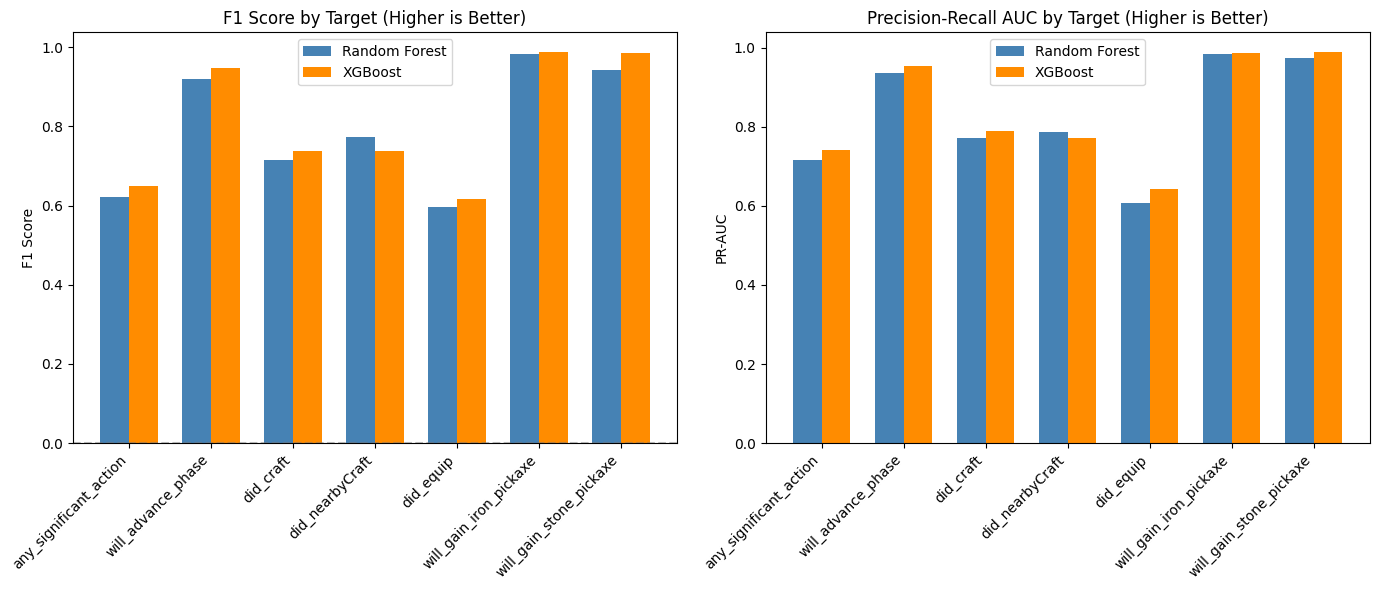

In [ ]:
# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# F1 Score comparison
x = range(len(summary_df))
width = 0.35

axes[0].bar([i - width/2 for i in x], summary_df['RF F1'], width, label='Random Forest', color='steelblue')
axes[0].bar([i + width/2 for i in x], summary_df['XGB F1'], width, label='XGBoost', color='darkorange')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 Score by Target (Higher is Better)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(summary_df['Target'], rotation=45, ha='right')
axes[0].legend()
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# PR-AUC comparison
axes[1].bar([i - width/2 for i in x], summary_df['RF PR-AUC'], width, label='Random Forest', color='steelblue')
axes[1].bar([i + width/2 for i in x], summary_df['XGB PR-AUC'], width, label='XGBoost', color='darkorange')
axes[1].set_ylabel('PR-AUC')
axes[1].set_title('Precision-Recall AUC by Target (Higher is Better)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(summary_df['Target'], rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Section 8: Feature Importance Analysis


Feature importance for: will_gain_iron_pickaxe


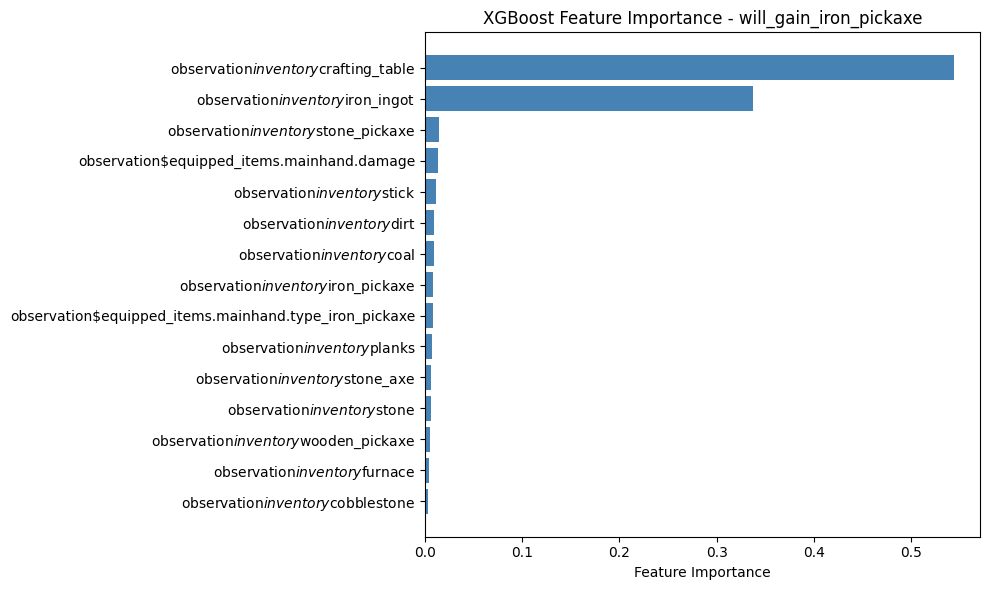

In [ ]:
def plot_feature_importance(model, feature_names, title, top_n=15):
    """
    Plot feature importances from a trained model.
    """
    importances = model.feature_importances_
    indices = np.argsort(importances)[-top_n:]

    plt.figure(figsize=(10, 6))
    plt.barh(range(len(indices)), importances[indices], color='steelblue')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Feature Importance')
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Plot feature importance for the best performing model
if all_results:
    best_result = max(all_results, key=lambda x: x['xgb_f1'])
    print(f"\nFeature importance for: {best_result['target']}")
    plot_feature_importance(
        best_result['xgb_model'],
        X_full.columns.tolist(),
        f"XGBoost Feature Importance - {best_result['target']}"
    )

---
## Section 9: Temporal Window Model

Build a model that uses features aggregated over time windows for better prediction.

In [ ]:
def create_temporal_features(states_df, window_sizes=[10, 50, 100]):
    """
    Create temporal features using rolling windows.
    Optimized to avoid DataFrame fragmentation by building all features
    in a dictionary first, then creating the DataFrame at once.
    """
    df = states_df.copy()

    # Get inventory columns
    inventory_cols = [c for c in df.columns if 'observation$inventory' in c]

    # Build all features in a dictionary first (avoids fragmentation)
    feature_dict = {}

    for window in window_sizes:
        for col in inventory_cols:
            item_name = col.split('$')[-1]

            # Rolling statistics
            feature_dict[f'{item_name}_mean_{window}'] = df[col].rolling(window, min_periods=1).mean()
            feature_dict[f'{item_name}_max_{window}'] = df[col].rolling(window, min_periods=1).max()
            feature_dict[f'{item_name}_std_{window}'] = df[col].rolling(window, min_periods=1).std().fillna(0)

            # Change over window
            feature_dict[f'{item_name}_delta_{window}'] = df[col].diff(window).fillna(0)

            # Trend (increasing = 1, decreasing/stable = 0)
            feature_dict[f'{item_name}_trend_{window}'] = (df[col] > df[col].shift(window)).astype(int)

    # Game phase features
    if 'game_phase' in df.columns:
        for window in window_sizes:
            feature_dict[f'phase_changed_{window}'] = (df['game_phase'] != df['game_phase'].shift(window)).astype(int)

    # Total inventory trend
    if 'total_inventory' in df.columns:
        for window in window_sizes:
            feature_dict[f'total_inv_delta_{window}'] = df['total_inventory'].diff(window).fillna(0)

    # Create DataFrame all at once (no fragmentation)
    new_features = pd.DataFrame(feature_dict)

    return new_features

In [ ]:
# Make sure temporal features are created and combined with original features
print("Creating temporal features...")
temporal_features = create_temporal_features(states_aligned, window_sizes=[10, 50, 100])
print(f"Temporal features shape: {temporal_features.shape}")

# Combine with original features
X_temporal = pd.concat([X_full.reset_index(drop=True), temporal_features.reset_index(drop=True)], axis=1)
X_temporal = X_temporal.fillna(0)
print(f"Combined features shape: {X_temporal.shape}")

Creating temporal features...


In [ ]:
# Train temporal model for "any_significant_action"
if 'any_significant_action' in targets.columns:
    target_col = 'any_significant_action'
    y = targets[target_col]

    print("\n" + "="*60)
    print("TEMPORAL MODEL - any_significant_action")
    print("="*60)

    # Create balanced dataset with temporal features
    X_train, X_test, y_train, y_test = create_balanced_dataset(
        X_temporal, y, target_col, ratio=3
    )

    if X_train is not None:
        temporal_results = train_and_evaluate(
            X_train, X_test, y_train, y_test,
            f"{target_col} (with temporal features)"
        )

        # Compare with non-temporal
        non_temporal = next((r for r in all_results if r['target'] == target_col), None)
        if non_temporal:
            print("\n--- Comparison: Original vs Temporal ---")
            print(f"Original XGB F1:  {non_temporal['xgb_f1']:.4f}")
            print(f"Temporal XGB F1:  {temporal_results['xgb_f1']:.4f}")
            print(f"Improvement:      {(temporal_results['xgb_f1'] - non_temporal['xgb_f1']):.4f}")


TEMPORAL MODEL - any_significant_action


NameError: name 'X_temporal' is not defined

---
## Section 10: Game Phase Transition Model

Train a specialized model to predict when players will advance to the next game phase.

In [ ]:
# Focus on phase transitions
if 'will_advance_phase' in targets.columns and 'current_phase' in targets.columns:
    print("\n" + "="*60)
    print("GAME PHASE TRANSITION ANALYSIS")
    print("="*60)

    # Analyze phase distribution
    phase_counts = targets['current_phase'].value_counts().sort_index()
    print("\nPhase distribution:")
    phase_names = {
        0: "Gathering wood",
        1: "Crafting (has wood)",
        2: "Mining stone (wooden pickaxe)",
        3: "Mining iron (stone pickaxe)",
        4: "Mining diamond (iron pickaxe)"
    }
    for phase, count in phase_counts.items():
        if not pd.isna(phase):
            print(f"  Phase {int(phase)} ({phase_names.get(int(phase), 'Unknown')}): {count:,} frames")

    # Train phase-specific models
    for phase in range(4):  # Phases 0-3 can advance
        phase_mask = targets['current_phase'] == phase

        if phase_mask.sum() < 100:
            continue

        X_phase = X_temporal[phase_mask]
        y_phase = targets.loc[phase_mask, 'will_advance_phase']

        pos_count = y_phase.sum()
        if pos_count < 10:
            print(f"\nPhase {phase}: Insufficient positive samples ({pos_count})")
            continue

        print(f"\n--- Phase {phase}: {phase_names.get(phase, 'Unknown')} ---")
        print(f"Total samples: {len(y_phase):,}, Transitions: {pos_count:,}")

        # Create balanced dataset for this phase
        X_train, X_test, y_train, y_test = create_balanced_dataset(
            X_phase, y_phase, f"phase_{phase}_advance", ratio=3
        )

        if X_train is not None:
            phase_results = train_and_evaluate(
                X_train, X_test, y_train, y_test,
                f"Phase {phase} → {phase+1}"
            )

NameError: name 'targets' is not defined

---
## Section 11: Conclusions and Key Takeaways

### What We Learned:

1. **The Original Problem:** Per-frame action prediction fails because:
   - Extreme class imbalance (>99% "no action")
   - Models learn trivial "predict 0" solution
   - High accuracy but 0 F1 score

2. **Solutions That Help:**
   - **Balanced sampling:** Undersample majority class to ~25-33% positive rate
   - **Class weights:** Use `scale_pos_weight` in XGBoost, `class_weight='balanced'` in RF
   - **Better targets:** Predict state transitions or game phase changes instead of raw actions
   - **More data:** Aggregate all 122 players for more examples of rare events
   - **Temporal features:** Use rolling windows to capture dynamics

3. **Better Metrics:**
   - Use F1, PR-AUC, ROC-AUC instead of accuracy
   - PR-AUC is most appropriate for imbalanced data

4. **Most Meaningful Predictions:**
   - "Will inventory change?" - More balanced, more useful
   - "Will player advance game phase?" - Captures key progression
   - "Any significant action in next N frames?" - Aggregates sparse events

In [ ]:
# Final summary
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

if all_results:
    print("\nBest performing targets (by XGBoost F1):")
    sorted_results = sorted(all_results, key=lambda x: x['xgb_f1'], reverse=True)
    for i, r in enumerate(sorted_results[:5], 1):
        print(f"  {i}. {r['target']}: F1={r['xgb_f1']:.4f}, PR-AUC={r['xgb_ap']:.4f}")

print("\nKey improvements over original approach:")
print("  ✓ Non-zero F1 scores (original: 0.0)")
print("  ✓ Meaningful predictions with balanced precision/recall")
print("  ✓ Actionable insights from feature importance")
print("  ✓ Proper evaluation metrics for imbalanced data")